In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    ReLU, Add, GlobalAveragePooling1D, Dense
)
from tensorflow.keras.models import Model



2025-12-31 13:31:41.461959: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-31 13:31:41.474569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767162701.489264  512291 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767162701.493976  512291 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767162701.505250  512291 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
!free -h


               total        used        free      shared  buff/cache   available
Mem:            31Gi       7.4Gi        16Gi       703Mi       8.6Gi        23Gi
Swap:           14Gi       2.1Gi        12Gi


In [3]:
%whos


Variable                 Type        Data/Info
----------------------------------------------
Add                      type        <class 'keras.src.layers.merging.add.Add'>
BatchNormalization       type        <class 'keras.src.layers.<...>tion.BatchNormalization'>
Conv1D                   type        <class 'keras.src.layers.<...>olutional.conv1d.Conv1D'>
Dense                    type        <class 'keras.src.layers.core.dense.Dense'>
GlobalAveragePooling1D   type        <class 'keras.src.layers.<...>.GlobalAveragePooling1D'>
Input                    function    <function Input at 0x7840cd6b32e0>
Model                    type        <class 'keras.src.models.model.Model'>
ReLU                     type        <class 'keras.src.layers.activations.relu.ReLU'>
np                       module      <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
tf                       module      <module 'tensorflow' from<...>/tensorflow/__init__.py'>


In [4]:
data = np.load("preprocessingW64S64multifloat32/tow_ids_multi_preprocessedW64S64.npz")

X_train = data["x_train"]
y_train = data["y_train"]
X_val   = data["x_val"]
y_val   = data["y_val"]
X_test  = data["x_test"]
y_test  = data["y_test"]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(13165, 64, 64) (13165,)
(5643, 64, 64) (5643,)
(12368, 64, 64) (12368,)


In [5]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5])

In [6]:
def tcn_block(x, filters, kernel_size, dilation):
    shortcut = x

    x = Conv1D(filters, kernel_size,
               padding="causal",
               dilation_rate=dilation)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size,
               padding="causal",
               dilation_rate=dilation)(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same")(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    Dropout,
    MaxPooling1D,
    Flatten,
    Dense
)

def build_mr_tcn_multiclass(
    input_shape=(64, 64),
    num_classes=6,
    dropout_rate=0.55
):
    model = Sequential()

    # Explicit Input layer (best practice for paper)
    model.add(Input(shape=input_shape))

    # Conv1D Block 1
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=1,
        padding="same",
        activation="relu"
    ))
    model.add(Dropout(dropout_rate))

    # Conv1D Block 2
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=2,
        padding="same",
        activation="relu"
    ))
    model.add(Dropout(dropout_rate))

    # Conv1D Block 3
    model.add(Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        dilation_rate=4,
        padding="same",
        activation="relu"
    ))
    model.add(Dropout(dropout_rate))

    # Temporal Downsampling
    model.add(MaxPooling1D(pool_size=8, strides=8))

    # Flatten
    model.add(Flatten())
    model.add(Dropout(dropout_rate))

    # Multiclass Classification Head
    model.add(Dense(
        num_classes,
        activation="softmax"
    ))

    return model


In [8]:
model = build_mr_tcn_multiclass(
    input_shape=(64, 64),
    num_classes=6,
    dropout_rate=0.55
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


I0000 00:00:1767162704.672159  512291 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4136 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,134 (156.77 KB)

 Trainable params: 40,134 (156.77 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_mr_tcn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


In [10]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=700,
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)



Epoch 1/700


I0000 00:00:1767162705.995400  512437 service.cc:152] XLA service 0x783f2801c550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767162705.995416  512437 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-12-31 13:31:46.017588: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767162706.144011  512437 cuda_dnn.cc:529] Loaded cuDNN version 91200


 82/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1042 - loss: 3.9070

I0000 00:00:1767162708.867512  512437 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1153 - loss: 3.6331
Epoch 1: val_loss improved from None to 1.81702, saving model to best_mr_tcn.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.1319 - loss: 3.2533 - val_accuracy: 0.1327 - val_loss: 1.8170
Epoch 2/700
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1792 - loss: 2.5560
Epoch 2: val_loss improved from 1.81702 to 1.71630, saving model to best_mr_tcn.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2011 - loss: 2.4239 - val_accuracy: 0.4299 - val_loss: 1.7163
Epoch 3/700
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2618 - loss: 2.1037
Epoch 3: val_loss improved from 1.71630 to 1.67933, saving model to best_mr_tcn.keras
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2722 - loss: 2.0776 - val_accuracy: 0.4707 - val_loss: 1.6793
Epoch 4/700
202/206 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3066 - loss: 1.9733
Epoch 4: val_loss improved from 1.67933 to 1.66620, savi

In [11]:
test_results = model.evaluate(X_test, y_test, verbose=0)

for name, val in zip(model.metrics_names, test_results):
    print(f"{name}: {val:.4f}")


loss: 0.5113
compile_metrics: 0.8706


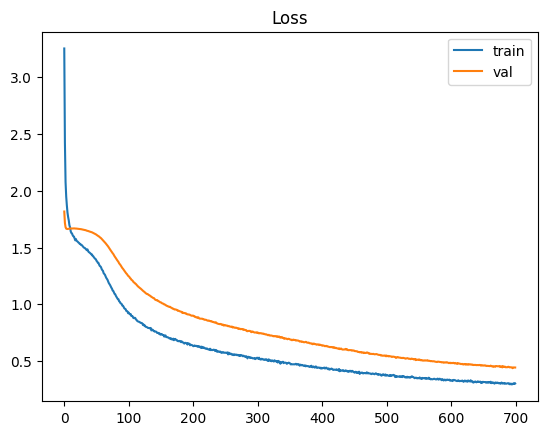

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")
plt.show()


387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


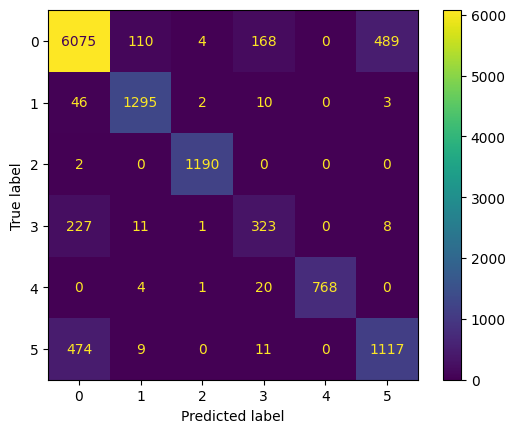

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()


In [14]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test, y_pred,
    target_names=['Normal','C_D','P_I','F_I','M_F','C_R']
))


              precision    recall  f1-score   support

      Normal       0.89      0.89      0.89      6846
         C_D       0.91      0.96      0.93      1356
         P_I       0.99      1.00      1.00      1192
         F_I       0.61      0.57      0.59       570
         M_F       1.00      0.97      0.98       793
         C_R       0.69      0.69      0.69      1611

    accuracy                           0.87     12368
   macro avg       0.85      0.84      0.85     12368
weighted avg       0.87      0.87      0.87     12368



In [15]:
import numpy as np

y_prob = model.predict(X_test)          # probabilitas
y_pred = np.argmax(y_prob, axis=1)      # label prediksi


387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step


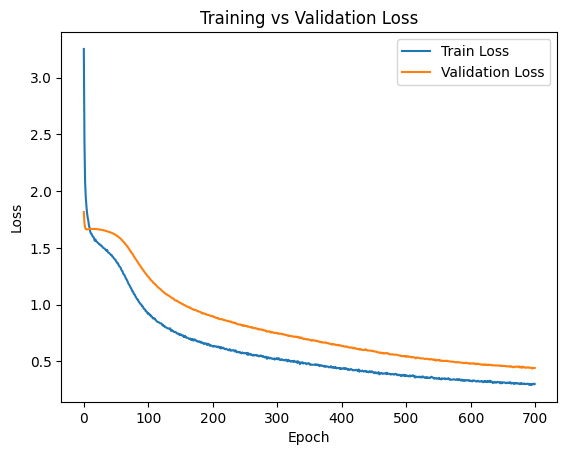

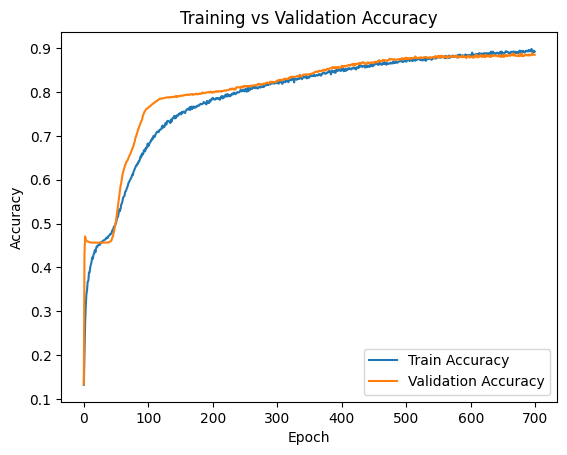

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()
# Gap kecil & kurva sejajar → tidak overfitting.

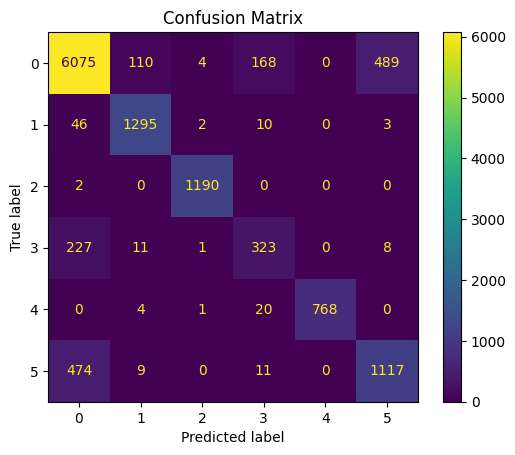

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()


# FN (Attack → Normal) harus minimal.

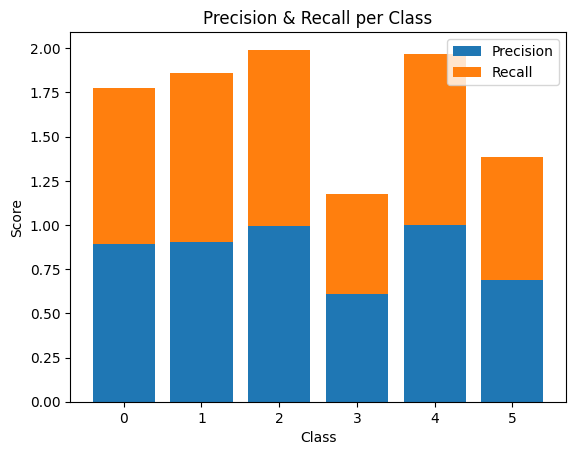

In [18]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None
)

classes = np.arange(len(precision))

plt.figure()
plt.bar(classes, precision, label='Precision')
plt.bar(classes, recall, bottom=precision, label='Recall')
plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Precision & Recall per Class')
plt.legend()
plt.show()
# Recall tinggi pada kelas Attack → IDS efektif.

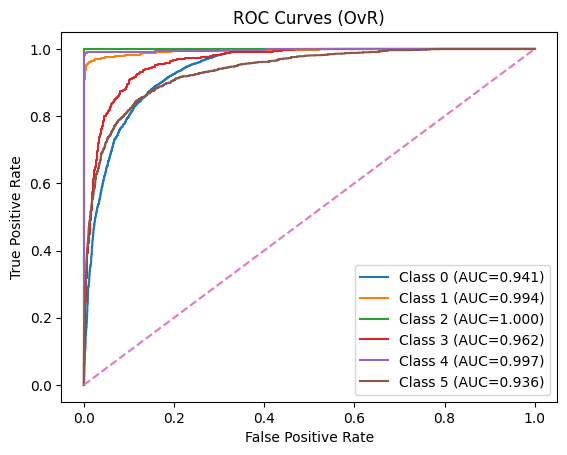

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = y_prob.shape[1]
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure()
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.3f})')

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (OvR)')
plt.legend()
plt.show()
# AUC → 1 = deteksi sangat kuat.

Threshold Optimal : 0.6070
Best F1-score     : 0.8508


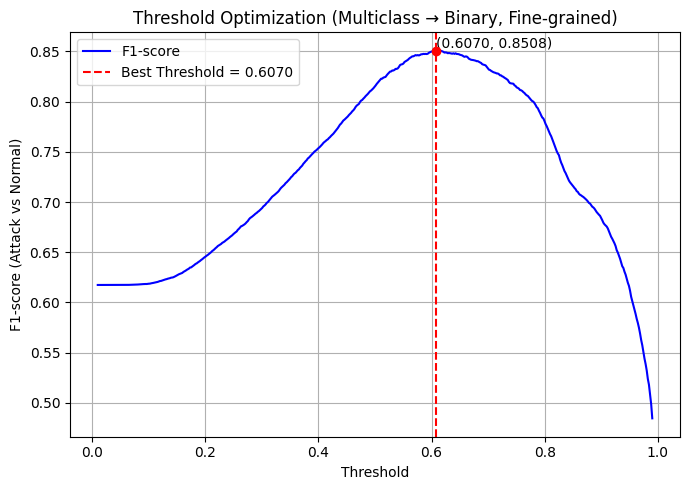

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Threshold grid halus
thresholds = np.linspace(0.01, 0.99, 500)
f1_scores = []

# Daftar kelas attack
attack_classes = [1, 2, 3, 4, 5]

# Gabungkan probabilitas semua attack
attack_prob = y_prob[:, attack_classes].sum(axis=1)

# Ground truth binary (Normal=0, Attack=1)
y_true_bin = np.isin(y_test, attack_classes).astype(int)

# Hitung F1-score untuk tiap threshold
for t in thresholds:
    y_pred_bin = (attack_prob >= t).astype(int)
    f1_scores.append(f1_score(y_true_bin, y_pred_bin))

f1_scores = np.array(f1_scores)

# Threshold terbaik
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Threshold Optimal : {best_threshold:.4f}")
print(f"Best F1-score     : {best_f1:.4f}")

# Plot
plt.figure(figsize=(7,5))
plt.plot(thresholds, f1_scores, label="F1-score", color='blue')
plt.scatter(best_threshold, best_f1, color='red', zorder=5)
plt.axvline(best_threshold, linestyle='--', color='red', label=f"Best Threshold = {best_threshold:.4f}")

# Anotasi angka
plt.text(
    best_threshold, best_f1,
    f"({best_threshold:.4f}, {best_f1:.4f})",
    ha='left', va='bottom'
)

plt.xlabel("Threshold")
plt.ylabel("F1-score (Attack vs Normal)")
plt.title("Threshold Optimization (Multiclass → Binary, Fine-grained)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--- Memulai Proses Evaluasi Multiclass → Binary ---
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step


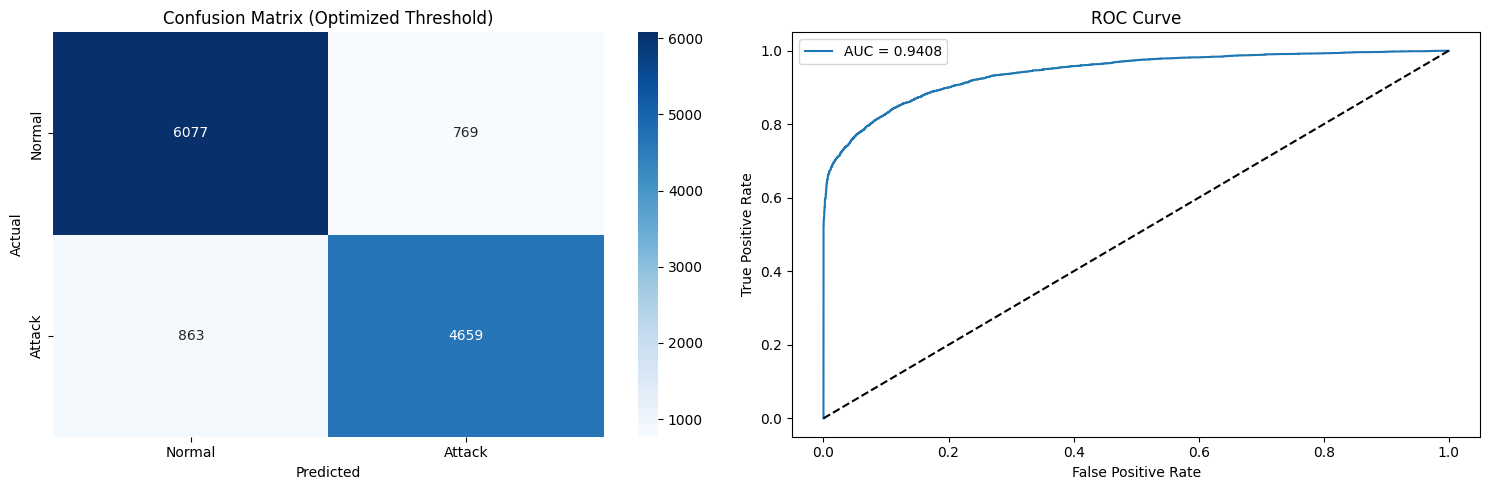


HASIL EVALUASI IDS (IoV)
Threshold Optimal : 0.6141
False Positive Rate: 0.112328
Inference Latency : 0.000042 s/sample
------------------------------
Classification Report (Normal vs Attack):
              precision    recall  f1-score   support

      Normal       0.88      0.89      0.88      6846
      Attack       0.86      0.84      0.85      5522

    accuracy                           0.87     12368
   macro avg       0.87      0.87      0.87     12368
weighted avg       0.87      0.87      0.87     12368



In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, f1_score

# 1. DEFINISI FUNGSI (Multiclass → Binary)
def evaluate_iov_model_multiclass(model, X_test, y_test, attack_classes=[1,2,3,4,5]):
    """
    Evaluasi model IDS IoV untuk multiclass → binary (Normal vs Attack)
    attack_classes: list kelas attack
    """
    print("--- Memulai Proses Evaluasi Multiclass → Binary ---")
    
    # Prediksi probabilitas
    start_time = time.time()
    y_prob = model.predict(X_test)  # bentuk (n_samples, n_classes)
    inference_time = (time.time() - start_time) / len(X_test)
    
    # Gabungkan probabilitas attack menjadi 1
    attack_prob = y_prob[:, attack_classes].sum(axis=1)  # bisa juga max/mean
    y_true_bin = np.isin(y_test, attack_classes).astype(int)
    
    # ROC Curve & Youden Index
    fpr, tpr, thresholds = roc_curve(y_true_bin, attack_prob)
    youden_index = tpr - fpr
    best_threshold = thresholds[np.argmax(youden_index)]
    
    # Klasifikasi berdasarkan threshold
    y_pred_bin = (attack_prob >= best_threshold).astype(int)
    
    # Confusion matrix & FPR
    cm = confusion_matrix(y_true_bin, y_pred_bin)
    tn, fp, fn, tp = cm.ravel()
    fpr_val = fp / (fp + tn)
    
    # Visualisasi
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    
    # Heatmap Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Confusion Matrix (Optimized Threshold)')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')
    ax[0].set_xticklabels(['Normal','Attack'])
    ax[0].set_yticklabels(['Normal','Attack'])
    
    # ROC Curve
    ax[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.4f}')
    ax[1].plot([0,1], [0,1], 'k--')
    ax[1].set_title('ROC Curve')
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Cetak hasil
    print("\n" + "="*30)
    print(f"HASIL EVALUASI IDS (IoV)")
    print("="*30)
    print(f"Threshold Optimal : {best_threshold:.4f}")
    print(f"False Positive Rate: {fpr_val:.6f}")
    print(f"Inference Latency : {inference_time:.6f} s/sample")
    print("-" * 30)
    print("Classification Report (Normal vs Attack):")
    print(classification_report(y_true_bin, y_pred_bin, target_names=['Normal','Attack']))
    
    return best_threshold

# ==========================================
# 2. EKSEKUSI FUNGSI
# ==========================================
try:
    best_thr = evaluate_iov_model_multiclass(model, X_test, y_test)
except NameError as e:
    print(f"Error: {e}. Pastikan variabel model dan data Anda sudah didefinisikan sebelumnya.")


In [22]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score
)

def compute_ids_metrics_multiclass(y_true, y_pred):
    """
    Multiclass IDS metrics:
    Accuracy, F1-macro, F1-weighted
    """

    cm = confusion_matrix(y_true, y_pred)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    return {
        "Accuracy": acc,
        "F1-macro": f1_macro,
        "F1-weighted": f1_weighted,
        "ConfusionMatrix": cm
    }


In [23]:
metrics = compute_ids_metrics_multiclass(y_test, y_pred)

for k, v in metrics.items():
    if isinstance(v, np.ndarray):
        print(f"{k}:\n{v}")
    else:
        print(f"{k:12s}: {v:.6f}")


Accuracy    : 0.870634
F1-macro    : 0.846144
F1-weighted : 0.870165
ConfusionMatrix:
[[6075  110    4  168    0  489]
 [  46 1295    2   10    0    3]
 [   2    0 1190    0    0    0]
 [ 227   11    1  323    0    8]
 [   0    4    1   20  768    0]
 [ 474    9    0   11    0 1117]]


In [24]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)
print({
    "accuracy": report["accuracy"],
    "macro_f1": report["macro avg"]["f1-score"],
    "weighted_f1": report["weighted avg"]["f1-score"]
})


{'accuracy': 0.8706338939197931, 'macro_f1': 0.8461444114609299, 'weighted_f1': 0.8701654771956613}
